In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams 
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles 
import seaborn as sns


In [2]:
X , y = make_circles(n_samples=100, noise = 0.1, random_state=1)

<Axes: >

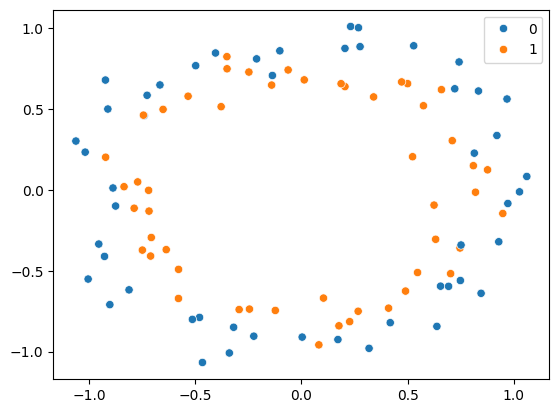

In [3]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y)

In [4]:
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size = 0.2, random_state=2)

In [5]:
model = Sequential()
model.add(Dense(16, input_dim=2, activation='relu'))   # smaller hidden layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1784540156.138463      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784540156.141740      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
model.compile(loss='binary_crossentropy', optimizer ='adam', metrics=['accuracy'])

In [7]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=1000, verbose=1)

Epoch 1/1000
1/3 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.5000 - loss: 0.6898

I0000 00:00:1784540160.236578      70 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 482ms/step - accuracy: 0.5000 - loss: 0.6912 - val_accuracy: 0.4000 - val_loss: 0.7145
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5125 - loss: 0.6907 - val_accuracy: 0.4000 - val_loss: 0.7142
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5125 - loss: 0.6903 - val_accuracy: 0.4000 - val_loss: 0.7144
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5250 - loss: 0.6899 - val_accuracy: 0.4000 - val_loss: 0.7144
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5250 - loss: 0.6896 - val_accuracy: 0.4000 - val_loss: 0.7146
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5250 - loss: 0.6894 - val_accuracy: 0.4000 - val_loss: 0.7146
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5375 - loss: 0.6890 - val_accuracy: 0.4000 - val_loss: 0.7149
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5375 - loss: 0.6887 - val_accuracy: 0.4000 - val_loss: 0.7

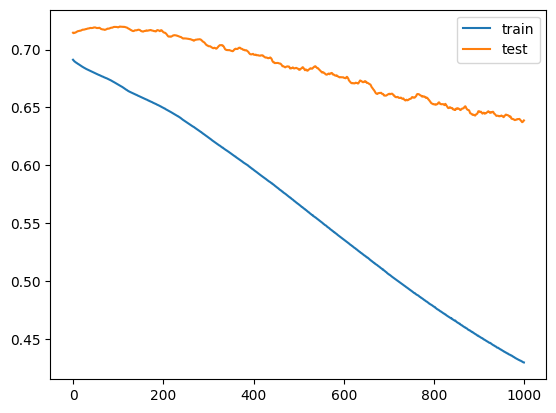

In [8]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

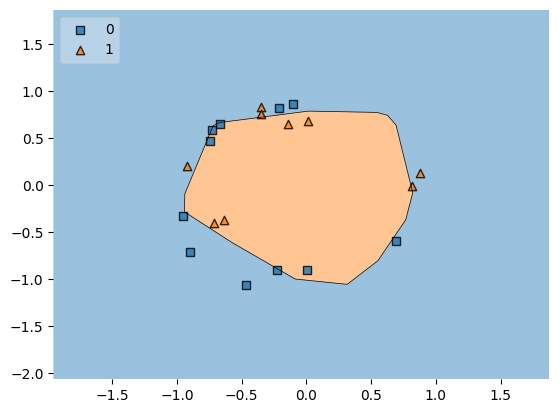

In [9]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.5500


# Now Early-Stopping

In [11]:
model = Sequential()
model.add(Dense(32, input_dim=2, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [12]:
model.compile(loss='binary_crossentropy', optimizer ='adam', metrics=['accuracy'])

In [13]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=10,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=True
)

In [14]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 626ms/step - accuracy: 0.5000 - loss: 0.6959 - val_accuracy: 0.3000 - val_loss: 0.7034
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5250 - loss: 0.6928 - val_accuracy: 0.3000 - val_loss: 0.7040
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5000 - loss: 0.6918 - val_accuracy: 0.3500 - val_loss: 0.7055
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4875 - loss: 0.6904 - val_accuracy: 0.4000 - val_loss: 0.7064
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5250 - loss: 0.6888 - val_accuracy: 0.4000 - val_loss: 0.7073
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5250 - loss: 0.6882 - val_accuracy: 0.4000 - val_loss: 0.7080
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5250 - loss: 0.6870 - val_accuracy: 0.4000 - val_loss: 0.7086
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5250 - loss: 0.6864 - val_accuracy: 0.4000 - 

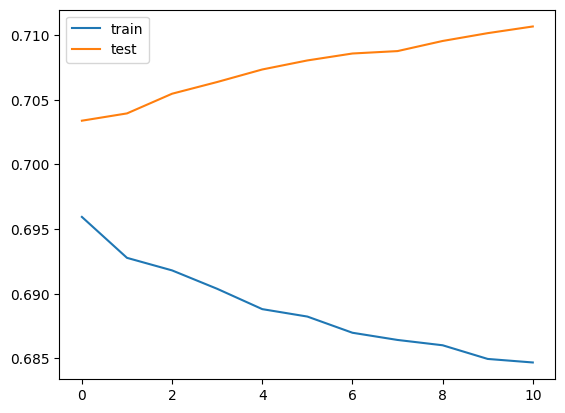

In [15]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


<Axes: >

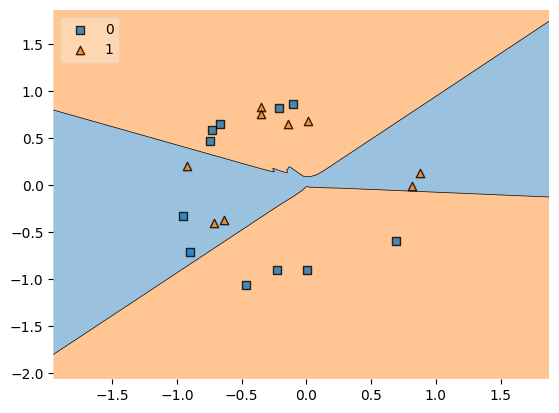

In [16]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)